In [ ]:
# ================================================================================
# 🎯 PENDEKATAN 3: RE-RUN GridSearchCV PADA FULL DATA
# ================================================================================
# TUJUAN: Mendapatkan SATU set parameter terbaik final untuk setiap scenario
# METODOLOGI: Gold standard untuk penelitian - memaksimalkan data untuk final model
# ================================================================================

print("=" * 80)
print("🎯 TAHAP FINAL: GridSearchCV pada FULL DATA")
print("=" * 80)
print("⚠️  PENTING:")
print("   • Nested CV (5x5) memberikan estimasi performa OBJEKTIF")
print("   • GridSearchCV ini untuk mendapat PARAMETER FINAL model deployment")
print("   • Performa yang dilaporkan tetap dari Nested CV, BUKAN dari sini!")
print("=" * 80)
print()

import time
waktu_mulai_final = time.time()

final_best_params = []

for scenario_name, param_grid in param_grids.items():
    print(f"📍 {scenario_name.upper()}: Mencari best parameters pada FULL dataset...")
    
    # GridSearchCV pada SELURUH data
    final_grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,  # Gunakan inner_cv yang sama (5-fold)
        scoring=scoring,
        refit='f1',  # Refit dengan F1 score
        return_train_score=False,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit pada FULL data (X, y)
    final_grid_search.fit(X, y)
    
    # Simpan best parameters
    final_params = final_grid_search.best_params_
    
    # Format parameter untuk disimpan
    param_str_parts = []
    for key, value in final_params.items():
        # Remove 'feature_selector__' and 'model__' prefix
        clean_key = key.replace('feature_selector__', '').replace('model__', '')
        param_str_parts.append(f"{clean_key}={value}")
    
    final_param_string = ', '.join(param_str_parts) + f', scenario={scenario_name}'
    
    final_best_params.append({
        'Scenario': scenario_name,
        'Final_Best_Params_String': final_param_string,
        'Final_Best_Params_Dict': final_params,
        'Final_Best_CV_Score': final_grid_search.best_score_,  # Mean CV score
        'Final_Best_Model': final_grid_search.best_estimator_
    })
    
    print(f"   ✓ Best Params: {final_param_string}")
    print(f"   ✓ Cross-Val F1 Score: {final_grid_search.best_score_:.4f}")
    print()

# Create DataFrame for final results
df_final_params = pd.DataFrame(final_best_params)

waktu_final = time.time() - waktu_mulai_final

print("=" * 80)
print("✅ FINAL GridSearchCV SELESAI")
print("=" * 80)
print(f"⏱️  Waktu eksekusi: {waktu_final:.1f} detik ({waktu_final/60:.1f} menit)")
print()

# ================================================================================
# 📊 MENAMBAHKAN FINAL PARAMETERS KE df_cv_biasa
# ================================================================================

# Extract clean parameters from Final_Best_Params_String
def extract_final_params(params_string):
    """Extract final best parameters from string format"""
    params_dict = {}
    for item in params_string.split(', '):
        if '=' in item and 'scenario' not in item:
            key, value = item.split('=', 1)
            # Try to convert to appropriate type
            try:
                if '.' in value:
                    value = float(value)
                else:
                    value = int(value)
            except:
                pass  # Keep as string
            params_dict[key] = value
    
    return {
        'Final_PCC_Threshold': params_dict.get('pcc_thresh'),
        'Final_Chi2_K': params_dict.get('chi2_k'),
        'Final_ETC_n_estimators': params_dict.get('etc_n_estimators'),
        'Final_XGB_n_estimators': params_dict.get('xgb_n_estimators')
    }

# Add final parameters to df_cv_biasa
final_param_extracted = df_final_params['Final_Best_Params_String'].apply(extract_final_params).apply(pd.Series)
df_cv_biasa_with_final = pd.concat([df_cv_biasa, final_param_extracted], axis=1)

print("=" * 80)
print("📊 DATAFRAME DENGAN FINAL PARAMETERS")
print("=" * 80)
print("Kolom yang ditambahkan:")
print("   • Final_PCC_Threshold: Threshold PCC terbaik dari full data")
print("   • Final_Chi2_K: K optimal Chi2 dari full data")
print("   • Final_ETC_n_estimators: n_estimators ETC terbaik dari full data")
print("   • Final_XGB_n_estimators: n_estimators XGB terbaik dari full data")
print()
display(df_cv_biasa_with_final)

# ================================================================================
# 💡 INTERPRETASI HASIL
# ================================================================================

print()
print("=" * 80)
print("💡 CARA MEMBACA HASIL INI:")
print("=" * 80)
print()
print("1️⃣  PERFORMA MODEL (dari Nested CV):")
print("   • Test_Accuracy_Mean, Test_F1_Mean, dll.")
print("   • INI adalah estimasi performa OBJEKTIF (unbiased)")
print("   • Gunakan angka INI untuk melaporkan performa model")
print()
print("2️⃣  PARAMETER TERBAIK (dari Final GridSearchCV):")
print("   • Final_PCC_Threshold, Final_Chi2_K, dll.")
print("   • INI adalah parameter untuk DEPLOY model ke production")
print("   • Train final model dengan parameter INI pada FULL data")
print()
print("3️⃣  WORKFLOW DEPLOYMENT:")
print("   a. Report performa: Test_Accuracy_Mean (dari Nested CV)")
print("   b. Train final model: Gunakan Final_* parameters pada FULL data")
print("   c. Deploy: Model final siap untuk production")
print()
print("=" * 80)
print("🎓 BEST PRACTICE DARI LITERATUR:")
print("=" * 80)
print("• Cawley & Talbot (2010): 'On over-fitting in model selection'")
print("• Varma & Simon (2006): 'Bias in error estimation'")
print("• Scikit-learn Documentation: 'Nested Cross-Validation'")
print("=" * 80)
print()

# ================================================================================
# 📝 CONTOH PENGGUNAAN FINAL MODEL
# ================================================================================

print("=" * 80)
print("📝 CONTOH: Deploy Final Model untuk Scenario BASELINE")
print("=" * 80)

baseline_final_model = df_final_params[df_final_params['Scenario'] == 'baseline']['Final_Best_Model'].values[0]
baseline_test_acc = df_cv_biasa_with_final[df_cv_biasa_with_final['Scenario'] == 'baseline']['Test_Accuracy_Mean'].values[0]

print(f"✓ Final Model telah di-train pada FULL data")
print(f"✓ Expected Test Accuracy: {baseline_test_acc:.4f} (dari Nested CV)")
print(f"✓ Model siap untuk prediction:")
print()
print("   # Contoh prediction:")
print("   # predictions = baseline_final_model.predict(X_new_data)")
print()
print("=" * 80)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import chi2

from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

import scipy.stats as stats
import scikit_posthocs as sp


In [26]:
data = pd.read_csv("dataset.csv")
# data = data.drop_duplicates().reset_index(drop=True)

data["ca"] = data["ca"].replace(4, 3)
data["thal"] = data["thal"].replace(0, 1)

target_col = "target"


In [27]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

X = data.drop(columns=[target_col])
y = data[target_col]


In [28]:
num_imp = SimpleImputer(strategy="median")
cat_imp = SimpleImputer(strategy="most_frequent")

X[numeric_features] = num_imp.fit_transform(X[numeric_features])
X[categorical_features] = cat_imp.fit_transform(X[categorical_features])

scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])


/var/folders/gw/gq2zg3153w3_vsgv27j97jcc0000gp/T/ipykernel_90742/1259561598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=['#FF6B6B', "steelblue"])


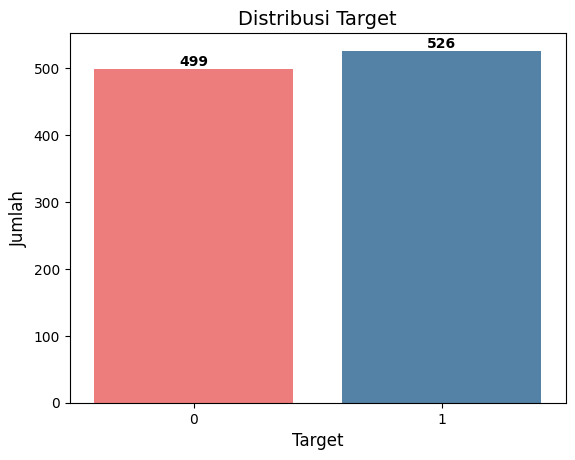

In [41]:
# Sebelum cleaning
# axes[0].bar(['Data'], [jumlah_baris_awal], color='#FF6B6B', alpha=0.7, width=0.5)
# axes[0].bar(['Duplikat'], [jumlah_duplikat], color='#95E1D3', alpha=0.7,
#             width=0.5, bottom=[jumlah_baris_awal-jumlah_duplikat])
# axes[0].set_ylabel('Jumlah Baris', fontsize=12, fontweight='bold')
# axes[0].set_title('Sebelum Cleaning', fontsize=14, fontweight='bold')
# axes[0].legend(['Data Unik', 'Duplikat'])
# axes[0].text(0, jumlah_baris_awal/2, f'{jumlah_baris_awal} total\n{jumlah_duplikat} duplikat',
#              ha='center', fontweight='bold')

sns.countplot(x=y, palette=['#FF6B6B', "steelblue"])
plt.title("Distribusi Target", fontsize=14)
plt.xlabel("Target", fontsize=12)
plt.ylabel("Jumlah", fontsize=12)
axes = plt.gca()
for p in axes.patches:
    height = int(p.get_height())
    axes.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.show()

# sns.heatmap(
#     data[numeric_features + [target_col]].corr(),
#     annot=True, cmap="coolwarm"
# )
# plt.title("Korelasi Fitur Numerik")
# plt.show()


In [30]:
pcc_scores = (
    X[numeric_features]
    .corrwith(y)
    .abs()
    .sort_values(ascending=False)
)


In [31]:
chi2_scores, _ = chi2(X[categorical_features], y)
chi2_ranking = (
    pd.Series(chi2_scores, index=categorical_features)
    .sort_values(ascending=False)
)

print(chi2_scores)

print(chi2_ranking)

[ 24.37365008 217.82392171   1.47754962   9.73934262 130.47092725
  33.67394807 228.14756449  19.53036178]
ca         228.147564
cp         217.823922
exang      130.470927
slope       33.673948
sex         24.373650
thal        19.530362
restecg      9.739343
fbs          1.477550
dtype: float64


In [32]:
pcc_scores = (
    X[numeric_features]
    .corrwith(y)
    .abs()
    .sort_values(ascending=False)
)

pcc_scores

oldpeak     0.438441
thalach     0.422895
age         0.229324
trestbps    0.138772
chol        0.099966
dtype: float64

In [33]:
# PCC thresholds from quantiles
pcc_quantiles = [0.6, 0.7, 0.8, 0.9]
pcc_thresholds = pcc_scores.quantile(pcc_quantiles).values

# Chi2 k from feature ratio
chi2_ratios = [0.3, 0.5, 0.7, 1.0]
chi2_k_values = [
    max(1, int(len(categorical_features) * r))
    for r in chi2_ratios
]


print("PCC thresholds:", pcc_thresholds)
print("Chi2 k values:", chi2_k_values)

PCC thresholds: [0.30675233 0.38418111 0.42600465 0.43222296]
Chi2 k values: [2, 4, 5, 8]


In [34]:
def select_features(pcc_threshold=None, chi2_k=None):
    selected = []

    if pcc_threshold is not None:
        selected += pcc_scores[pcc_scores >= pcc_threshold].index.tolist()

    if chi2_k is not None:
        selected += chi2_ranking.head(chi2_k).index.tolist()

    return list(dict.fromkeys(selected))


In [35]:
def evaluate_etcxgb(X, y, features, n_estimators):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    metrics = {"acc": [], "prec": [], "rec": [], "f1": []}
    cms = []

    for tr, ts in skf.split(X, y):
        Xtr, Xts = X.iloc[tr][features], X.iloc[ts][features]
        ytr, yts = y.iloc[tr], y.iloc[ts]

        et = ExtraTreesClassifier(
            n_estimators=n_estimators,
            random_state=42
        )
        et.fit(Xtr, ytr)

        et_tr_pred = et.predict(Xtr)
        et_ts_pred = et.predict(Xts)

        xgb_tr = np.column_stack((Xtr, et_tr_pred))
        xgb_ts = np.column_stack((Xts, et_ts_pred))

        xgb = XGBClassifier(
            n_estimators=n_estimators,
            random_state=42,
            eval_metric="logloss",
            use_label_encoder=False
        )
        xgb.fit(xgb_tr, ytr)

        y_pred = xgb.predict(xgb_ts)

        metrics["acc"].append(accuracy_score(yts, y_pred))
        metrics["prec"].append(precision_score(yts, y_pred))
        metrics["rec"].append(recall_score(yts, y_pred))
        metrics["f1"].append(f1_score(yts, y_pred))
        cms.append(confusion_matrix(yts, y_pred))

    return {
        "accuracy_mean": np.mean(metrics["acc"]),
        "accuracy_std": np.std(metrics["acc"]),
        "precision_mean": np.mean(metrics["prec"]),
        "recall_mean": np.mean(metrics["rec"]),
        "f1_mean": np.mean(metrics["f1"]),
        "confusion_matrix": np.sum(cms, axis=0)
    }


In [36]:
# results = []
# n_estimators_list = [100, 200, 300]

# # Baseline
# for n in n_estimators_list:
#     res = evaluate_etcxgb(X, y, X.columns.tolist(), n)
#     results.append({
#         "Scenario": "Baseline",
#         "PCC_threshold": None,
#         "Chi2_k": None,
#         "n_estimators": n,
#         "Num_features": X.shape[1],
#         **res
#     })

# # PCC only
# for t in pcc_thresholds:
#     feats = select_features(pcc_threshold=t)
#     for n in n_estimators_list:
#         res = evaluate_etcxgb(X, y, feats, n)
#         results.append({
#             "Scenario": "PCC",
#             "PCC_threshold": round(float(t), 3),
#             "Chi2_k": None,
#             "n_estimators": n,
#             "Num_features": len(feats),
#             **res
#         })

# # Chi2 only
# for k in chi2_k_values:
#     feats = select_features(chi2_k=k)
#     for n in n_estimators_list:
#         res = evaluate_etcxgb(X, y, feats, n)
#         results.append({
#             "Scenario": "Chi2",
#             "PCC_threshold": None,
#             "Chi2_k": k,
#             "n_estimators": n,
#             "Num_features": len(feats),
#             **res
#         })

# # PCC + Chi2
# for t in pcc_thresholds:
#     for k in chi2_k_values:
#         feats = select_features(t, k)
#         for n in n_estimators_list:
#             res = evaluate_etcxgb(X, y, feats, n)
#             results.append({
#                 "Scenario": "PCC+Chi2",
#                 "PCC_threshold": round(float(t), 3),
#                 "Chi2_k": k,
#                 "n_estimators": n,
#                 "Num_features": len(feats),
#                 **res
#             })

# results_df = pd.DataFrame(results)


In [37]:
# pivot = results_df.pivot_table(
#     values="accuracy_mean",
#     index="Scenario",
#     columns="n_estimators"
# )

# friedman_stat, friedman_p = stats.friedmanchisquare(
#     *[pivot[c] for c in pivot.columns]
# )

# nemenyi = sp.posthoc_nemenyi_friedman(pivot.values)
# nemenyi.index = pivot.index
# nemenyi.columns = pivot.index
